#### Imports

In [1]:
import os
import pandas as pd
from PIL import Image
import random
import matplotlib.pyplot as plt

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#### Initial Information

In [2]:
# Folder path for images
folder_path = '10000_random_files'

In [3]:
# List to store image information
image_data = []

# Count images by file type
image_counts = {}

# Count non-grayscale images
non_grayscale_count = 0

# Loop through the files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):  # Different file extensions
        # Get the full path of the image
        img_path = os.path.join(folder_path, filename)
        
        # Open the image
        with Image.open(img_path) as img:
            # Check if the image is grayscale
            if img.mode != 'L':
                non_grayscale_count += 1  # Count non-grayscale images
                continue  # Skip if the image is not grayscale
            
            # Store the information
            img_type = filename.split('.')[-1]  # Image extension
            img_width, img_height = img.size
            
            # Add to the list
            image_data.append([filename, img_type, img_width, img_height])
            
            # Count images by type
            if img_type not in image_counts:
                image_counts[img_type] = 0
            image_counts[img_type] += 1

# Save the information to a CSV
df = pd.DataFrame(image_data, columns=['Filename', 'Type', 'Width', 'Height'])
df.to_csv('image_review.csv', index=False)

# Print the number of images of each type
print("Number of images of each type:")
for img_type, count in image_counts.items():
    print(f"{img_type}: {count} images")

# Print the count of non-grayscale images
print(f"Number of non-grayscale images: {non_grayscale_count}")

# Additional useful information you might want to check
print(f"Total number of images: {len(image_data)}")

Number of images of each type:
jpg: 8653 images
png: 1324 images
jpeg: 18 images
Number of non-grayscale images: 0
Total number of images: 9995


In [4]:
# Load the CSV file containing image information
df = pd.read_csv('image_review.csv')

# Group by width and height and count occurrences
size_counts = df.groupby(['Width', 'Height']).size().reset_index(name='Count')

# Print the size and count of each unique image dimension
for index, row in size_counts.iterrows():
    print(f"Size: {row['Width']}x{row['Height']} - Count: {row['Count']} images")


Size: 800x600 - Count: 9995 images


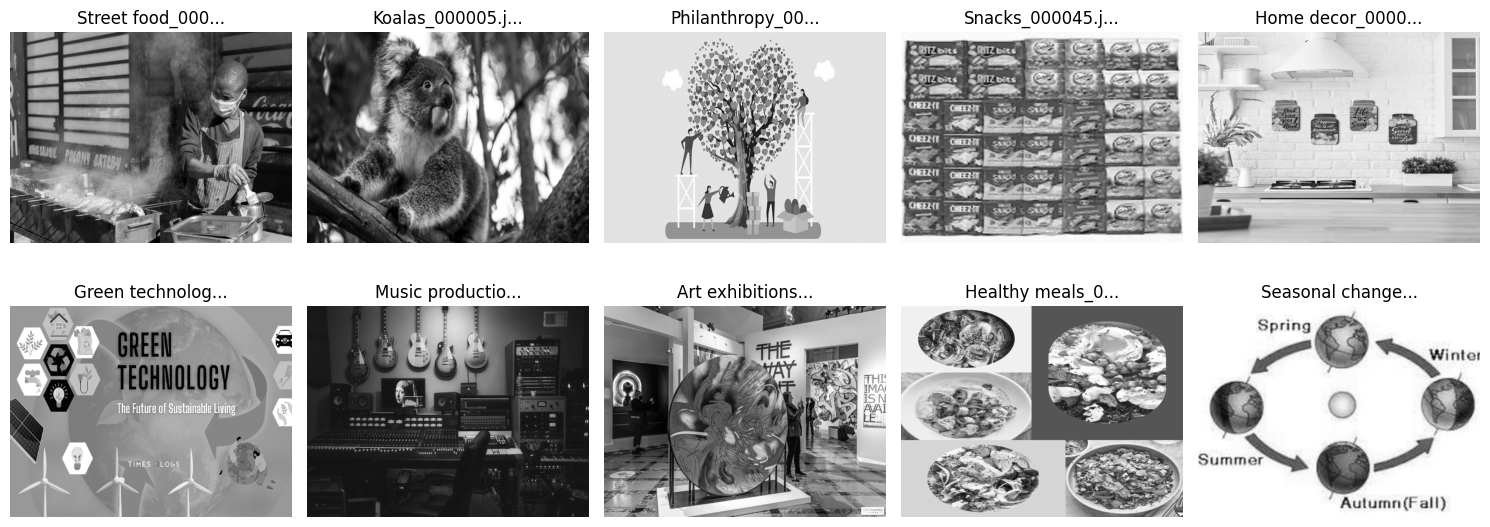

In [5]:
# Display 10 random grayscale images in 2 rows of 5
if len(image_data) >= 10:
    # Select 10 random images
    random_images = random.sample(image_data, 10)
    
    # Set up the plot with 2 rows and 5 columns
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # Loop through the selected images and display them
    for i, (filename, img_type, width, height) in enumerate(random_images):
        img_path = os.path.join(folder_path, filename)
        with Image.open(img_path) as img:
            ax = axes[i // 5, i % 5]  # Determine position in 2x5 grid
            ax.imshow(img, cmap='gray')  # Display image in grayscale
            ax.axis('off')  # Turn off axis
            ax.set_title(f'{filename[:15]}...')  # Display first 15 characters of filename
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough images to display 10 random ones.")


#### PreProcessing

Converting image formats to a fixed format (Uniform Format Conversion)

In [6]:
def convert_folder_images(input_folder, output_folder):
    # Check if output folder exists, if not, create it
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Loop over all files in the input folder
    for image_name in os.listdir(input_folder):
        image_path = os.path.join(input_folder, image_name)
        
        # Only process non-PNG files
        if image_name.lower().endswith(('jpg', 'jpeg')):
            # Convert and save in the output folder
            new_image_path = os.path.join(output_folder, image_name.replace(image_name.split('.')[-1], 'png'))
            image = Image.open(image_path)
            image = image.convert('L')  # Convert to grayscale
            image.save(new_image_path, 'PNG')
            print(f"Converted {image_name} to PNG.")
    
    print("Conversion process completed!")

In [ ]:
input_folder = "path_to_your_folder"  # Replace with your input folder path
output_folder = "path_to_output_folder"  # Replace with your output folder path
convert_folder_images(input_folder, output_folder)
